# <center> <b> Applied Machine Learning (CMSE 890)  project </b> </center>
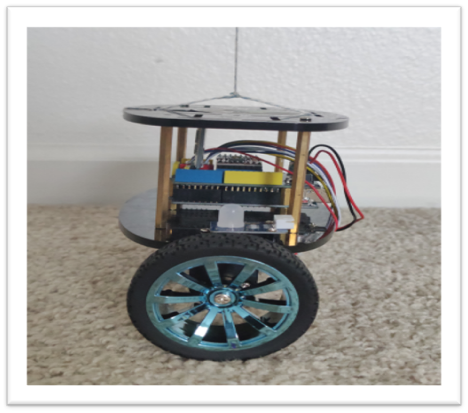

In [3]:
#!pip install stable-baselines3[extra]
#!pip install stable-baselines
#!pip install tensorflow==2.3.0
#!pip install gym==0.21.0
#!pip install keras
#!pip install keras-rl2
#!pip install tensorboard
#pip install pygame

In [4]:
#print('gym:', gym.__version__)b

In [5]:
#from platform import python_version
#print(python_version())

In [6]:
import torch
torch.manual_seed(0)

In [191]:
import gym
from gym import Env
from gym.spaces import Discrete, Box, Dict, Tuple, MultiBinary, MultiDiscrete 
import numpy as np
import random
import os
import time
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.evaluation import evaluate_policy

### Create custom Inverted pendulum Robot environment from existing cartpole-v1 of open AI gym with robot's physical parameters

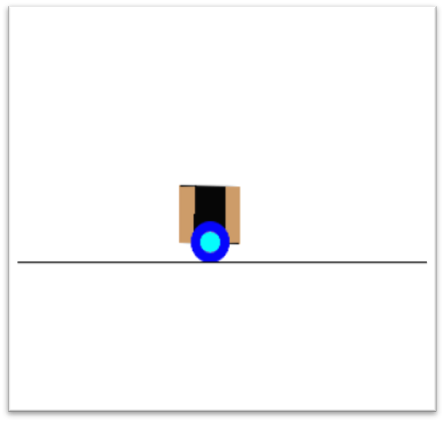

In [220]:
import math
from typing import Optional, Union

import numpy as np

import gym
from gym import Env
from gym import logger, spaces
from gym.utils import seeding


class CustomCartPoleEnv(Env):
    """
    ### Description

    This environment is a modified version of the cart-pole problem
    described by Barto, Sutton, and Anderson in ["Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem"](https://ieeexplore.ieee.org/document/6313077).
    
    In the classical cart-pole problem, the pole is attached by an un-actuated joint to a cart, which moves along a
    frictionless track. The pendulum is placed upright on the cart and the goal is to balance the pole by applying forces in the left and right direction on the cart.
    
    In this modified version a similar mathematical model is used with physical parameters changed. While the vizualization is changed to match an inverted pendulum robot.
    The base of the robot abstracts to a cart and upright chassis abstracts to a pole.
    
    ### Action Space

    The action is a `ndarray` with shape `(1,)` which can take values `{0, 1}` indicating the direction of the fixed force the cart (base of the robot) is pushed with.

    | Num | Action                 |
    |-----|------------------------|
    | 0   | Push robot to the left  |
    | 1   | Push robot to the right |


    ### Observation Space

    The observation is a `ndarray` with shape `(4,)` with the values corresponding to the following positions and velocities:

    | Num | Observation           | Min                  | Max                |
    |-----|-----------------------|----------------------|--------------------|
    | 0   | Cart Position (m)     | -1.0                 | 1.0                |
    | 1   | Cart Velocity (cm/s)  | -58.74               | 58.74              |
    | 2   | Pole Angle            | ~ -0.209 rad (-12°)  | ~ 0.209 rad (12°)  |
    | 3   | Pole Angular Velocity | -Inf                 | Inf                |


    ### Rewards

    Since the goal is to keep the pole upright for as long as possible, a reward of `+1` for every step taken, including the termination step, is allotted. The threshold for rewards is 1500.

    ### Starting State

    All observations are assigned a uniformly random value in `(-0.05, 0.05)`

    ### Episode Termination

    The episode terminates if any one of the following occurs:
    1. Pole Angle is greater than ±12°
    2. Cart Position is greater than ±1.0 (center of the cart reaches the edge of the display)
    3. Episode length is greater than 1500

    """

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 50}

    def __init__(self):
        self.gravity = 9.8
        self.masscart = 0.642
        self.masspole = 0.113
        self.total_mass = self.masspole + self.masscart
        self.length = 0.044  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag = 2*2.376
        self.tau = 0.02  # seconds between state updates
        self.kinematics_integrator = "euler"
        self.max_episode = 15000 # 6000 = 2 mins real time # 15000 = 5 mins of real time

        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 1.0

        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array(
            [
                self.x_threshold * 2,
                #np.finfo(np.float32).max,
                0.5874, # 170 RPM max for motor and diameter of wheel 6.6 cm, hence max velocity = 58.74 cm/s. The experiment setup gives 0.74
                self.theta_threshold_radians * 2,
                np.finfo(np.float32).max,
            ],
            dtype=np.float32,
        )

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        self.screen = None
        self.clock = None
        self.isopen = True
        self.state = None

        self.steps_beyond_done = None

    def step(self, action):
        err_msg = f"{action!r} ({type(action)}) invalid"
        assert self.action_space.contains(action), err_msg
        assert self.state is not None, "Call reset before using step method."
        x, x_dot, theta, theta_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag
        costheta = math.cos(theta)
        sintheta = math.sin(theta)

        # For the interested reader:
        # https://coneural.org/florian/papers/05_cart_pole.pdf
        temp = (
            force + self.polemass_length * theta_dot**2 * sintheta
        ) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4.0 / 3.0 - self.masspole * costheta**2 / self.total_mass)
        )
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

        if self.kinematics_integrator == "euler":
            x = x + self.tau * x_dot
            x_dot = x_dot + self.tau * xacc
            theta = theta + self.tau * theta_dot
            theta_dot = theta_dot + self.tau * thetaacc
        else:  # semi-implicit euler
            x_dot = x_dot + self.tau * xacc
            x = x + self.tau * x_dot
            theta_dot = theta_dot + self.tau * thetaacc
            theta = theta + self.tau * theta_dot

        self.state = (x, x_dot, theta, theta_dot)
        self.max_episode -= 1

        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
            or self.max_episode <= 0
        )

        if not done:
            reward = 1.0
        elif self.steps_beyond_done is None:
            # Pole just fell!
            self.steps_beyond_done = 0
            reward = 1.0
        else:
            if self.steps_beyond_done == 0:
                logger.warn(
                    "You are calling 'step()' even though this "
                    "environment has already returned done = True. You "
                    "should always call 'reset()' once you receive 'done = "
                    "True' -- any further steps are undefined behavior."
                )
            self.steps_beyond_done += 1
            reward = 0.0

        return np.array(self.state, dtype=np.float32), reward, done, {}
    
    def reset(
        self,
        #*,
        return_info: bool = False,
        #options: Optional[dict] = None,
    ):
        
        #super().reset()
        self.max_episode = 15000 # 2 mins real time
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))
        self.steps_beyond_done = None
        if not return_info:
            return np.array(self.state, dtype=np.float32)
        else:
            return np.array(self.state, dtype=np.float32), {}
    
    def render(self, mode="human"):
        import pygame
        from pygame import gfxdraw

        screen_width = 900#600
        screen_height = 600#400

        world_width = self.x_threshold * 2
        scale = screen_width / world_width
        polewidth = int(scale*0.1)
        polelen = int(scale * (2 * self.length))
        
        #cartwidth = 50.0
        #cartheight = 30.0
        wheel_rad = int(scale*0.033)#9.9cm dia

        if self.state is None:
            return None

        x = self.state

        if self.screen is None:
            pygame.init()
            pygame.display.init()
            self.screen = pygame.display.set_mode((screen_width, screen_height))
        if self.clock is None:
            self.clock = pygame.time.Clock()

        self.surf = pygame.Surface((screen_width, screen_height))
        self.surf.fill((255, 255, 255))
        
        cartx = x[0] * scale + screen_width / 2.0  # MIDDLE OF wheel
        carty = int(screen_height/4) + wheel_rad  # TOP OF wheel
        
        axleoffset = polewidth / 2 #wheel_ra

        l, r, t, b = (
            -polewidth / 2,
            polewidth / 2,
            polelen - polewidth / 2,
            -polewidth / 2,
        )
        
        l1, r1, t1, b1 = (
            -polewidth / 4,
            polewidth / 4,
            polelen - polewidth / 2,
            -polewidth / 2,
        )

        pole_coords = []
        box_coords = []
        
        for coord in [(l1, b1), (l1, t1), (r1, t1), (r1, b1)]:
            coord = pygame.math.Vector2(coord).rotate_rad(-x[2])
            coord = (coord[0] + cartx, coord[1] + carty + axleoffset)
            box_coords.append(coord)
        
        for coord in [(l, b), (l, t), (r, t), (r, b)]:
            coord = pygame.math.Vector2(coord).rotate_rad(-x[2])
            coord = (coord[0] + cartx, coord[1] + carty + axleoffset)
            pole_coords.append(coord)
        
        gfxdraw.aapolygon(self.surf, pole_coords, (0, 0, 0))
        
        gfxdraw.filled_polygon(self.surf, pole_coords, (202, 152, 101))
        
        gfxdraw.filled_polygon(self.surf, box_coords, (0, 0, 0))
        
        gfxdraw.aacircle(self.surf, int(cartx), int(carty), wheel_rad, (0, 0, 250))
        gfxdraw.filled_circle(self.surf, int(cartx), int(carty), wheel_rad, (0, 0, 250))

        gfxdraw.aacircle(
            self.surf,
            int(cartx),
            #int(carty + axleoffset),
            int(carty),
            int(wheel_rad / 2),
            (129, 132, 203),
        )
        gfxdraw.filled_circle(
            self.surf,
            int(cartx),
            #int(carty + axleoffset),
            int(carty),
            int(wheel_rad / 2),
            (0, 250, 250),
        )
        
        
        gfxdraw.hline(self.surf, 0, screen_width, carty - wheel_rad, (0, 0, 0))

        self.surf = pygame.transform.flip(self.surf, False, True)
        self.screen.blit(self.surf, (0, 0))
        if mode == "human":
            pygame.event.pump()
            self.clock.tick(self.metadata["render_fps"])
            pygame.display.flip()

        if mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )
        else:
            return self.isopen

    def close(self):
        if self.screen is not None:
            import pygame

            pygame.display.quit()
            pygame.quit()
            self.isopen = False

### Check environment inputs (actions) and outputs (states)

In [10]:
custom_env = CustomCartPoleEnv()

In [11]:
custom_env.action_space #input

Discrete(2)

In [12]:
custom_env.observation_space #state

Box([-2.0000000e+00 -5.8740002e-01 -4.1887903e-01 -3.4028235e+38], [2.0000000e+00 5.8740002e-01 4.1887903e-01 3.4028235e+38], (4,), float32)

In [13]:
custom_env.observation_space.sample() # Try a random input(action) to the environment

array([1.5907104e+00, 1.5986401e-01, 4.1243663e-01, 5.0631167e+37],
      dtype=float32)

In [14]:
custom_env.reset()

array([-0.04637269,  0.00963689, -0.00556562,  0.026801  ], dtype=float32)

### Get a baseline score with random action 

pygame 2.1.0 (SDL 2.0.16, Python 3.9.7)
Hello from the pygame community. https://www.pygame.org/contribute.html


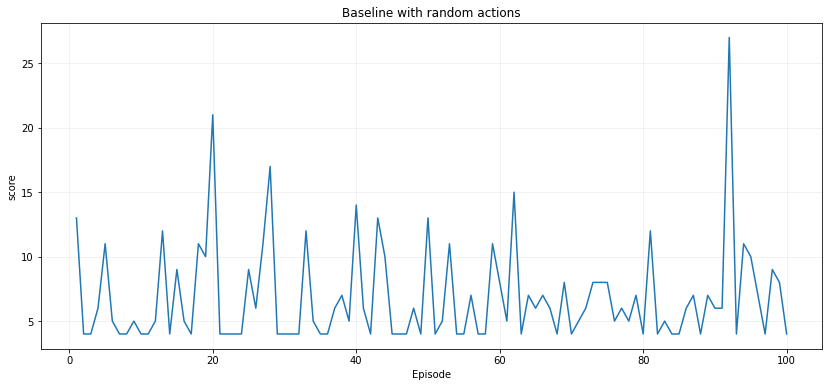

In [15]:
import matplotlib.pyplot as plt 

episodes = 100

episode_list = []
score_list = []

for episode in range(1, episodes+1):
    state = custom_env.reset()
    done = False
    score = 0
    
    while not done:
        custom_env.render()
        action = custom_env.action_space.sample()
        n_state, reward, done, info = custom_env.step(action)
        score+=reward
    #print('Episode:{} Score:{}'.format(episode, score))
    score_list.append(score)
    episode_list.append(episode)
    
fig = plt.figure(figsize=(14,6))
plt.plot(episode_list, score_list)
plt.ylabel('score')
plt.xlabel('Episode')
plt.title('Baseline with random actions')
plt.grid(alpha=0.2)

In [16]:
custom_env.close()

## To control the inverted pendulum robot, Model free reinforcement learning is employed using stable-baselines3.

Two policy based reinforcement learning algorithms are tested :- 
1. PPO - Proximal Policy Optimization Algorithms
2. A2C - Synchronous advantage actor critic 

and two Q-learning based reinforcement learning algorithms are tested:- 
1. DQN - Deep Q network
2. QR-DQN - Quantile Regression DQN

# PPO

In [17]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
import os

### Training the model with callback and training stop at score threshold with defined architechture

In [23]:
save_path = os.path.join('Training', 'Saved Models','PPO_models')
log_path = os.path.join('Training', 'Logs','PPO_models')

In [24]:
env = CustomCartPoleEnv()
env = DummyVecEnv([lambda: env])

Save the model which reaches the best score of 6000, every 10,000 steps

In [25]:
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=6000, verbose=1)# 6000 reward threshold because: 1 step = T = 0.02 sec assumed in the model. Hence 6000 steps = 2 minutes.
eval_callback = EvalCallback(env, 
                             callback_on_new_best=stop_callback, 
                             eval_freq=10000, 
                             best_model_save_path=save_path, 
                             verbose=1)

In [26]:
net_arch=[dict(pi=[128, 128, 128, 128], vf=[128, 128, 128, 128])]

In [27]:
PPOmodel = PPO('MlpPolicy', env, verbose = 1, tensorboard_log=log_path, policy_kwargs={'net_arch': net_arch})

Using cpu device


### 60,000 total training steps.

In [28]:
PPO_time_start = time.time()
PPOmodel.learn(total_timesteps=60000, callback=eval_callback)
PPO_time_stop = time.time()

Logging to Training\Logs\PPO_models\PPO_8
-----------------------------
| time/              |      |
|    fps             | 298  |
|    iterations      | 1    |
|    time_elapsed    | 6    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 448         |
|    iterations           | 2           |
|    time_elapsed         | 9           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.015890352 |
|    clip_fraction        | 0.382       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.678      |
|    explained_variance   | -0.022      |
|    learning_rate        | 0.0003      |
|    loss                 | 1.92        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0453     |
|    value_loss           | 6.02        |
----------------------------------

C:\Users\Sarthak M Desai\.conda\envs\tf2\lib\site-packages\stable_baselines3\common\evaluation.py:65: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=10000, episode_reward=332.20 +/- 146.36
Episode length: 332.20 +/- 146.36
-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 332         |
|    mean_reward          | 332         |
| time/                   |             |
|    total_timesteps      | 10000       |
| train/                  |             |
|    approx_kl            | 0.024123214 |
|    clip_fraction        | 0.159       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.434      |
|    explained_variance   | 0.197       |
|    learning_rate        | 0.0003      |
|    loss                 | 13.1        |
|    n_updates            | 40          |
|    policy_gradient_loss | -0.029      |
|    value_loss           | 34.1        |
-----------------------------------------
New best mean reward!
------------------------------
| time/              |       |
|    fps             | 632   |
|    iterations      | 5     |
|    

In [29]:
PPOtrain_time = PPO_time_stop -  PPO_time_start
print(PPOtrain_time)

61.36540651321411


Loading the saved model

In [30]:
model_path = os.path.join('Training', 'Saved Models','PPO_models', 'best_model')
model = PPO.load(model_path, env=env)

### NOTE: For presentation the following evaluate policy function was used: 

To get the scores used to plot the graphs in poster presentation, pass the following additional args and kwargs to evaluate_policy():

n_eval_episodes=100

return_episode_rewards=True (save the returned episode scores to a list)

NOTE : A step-by-step evalution of performance is done below, because the results from evalute policy function differs from the step-by-step evaluation. The evaluate policy function tends to return the perfect score of 15000 quite often, where as step by step evalution, returns more expected values.

In [31]:
evaluate_policy(model, env, n_eval_episodes=1, render=True)

(15000.0, 0.0)

In [32]:
env.close()

### Testing the trained model

Scroll to the bottom of the logs, to view the accompanying graph.

In [33]:
env = CustomCartPoleEnv()
env = DummyVecEnv([lambda: env])

In [34]:
model_path = os.path.join('Training', 'Saved Models', 'PPO_models', 'best_model')
model = PPO.load(model_path, env=env)

info [{'terminal_observation': array([ 0.257952  ,  0.02739774, -0.21311109, -0.63980347], dtype=float32)}]
Episode:1 Score:[3262.]
info [{'terminal_observation': array([-0.08253609,  0.23197511, -0.24727689, -1.4137266 ], dtype=float32)}]
Episode:2 Score:[200.]
info [{'terminal_observation': array([ 0.14198647, -0.1057591 , -0.21255043,  1.0775249 ], dtype=float32)}]
Episode:3 Score:[651.]
info [{'terminal_observation': array([-0.3677578 ,  0.01591719,  0.21422705, -1.2968956 ], dtype=float32)}]
Episode:4 Score:[5678.]
info [{'terminal_observation': array([ 0.13282125,  0.01155955, -0.2350403 , -0.9501313 ], dtype=float32)}]
Episode:5 Score:[290.]
info [{'terminal_observation': array([ 0.28372395, -0.03128319, -0.21437445,  0.4052417 ], dtype=float32)}]
Episode:6 Score:[4454.]
info [{'terminal_observation': array([-0.07653923,  0.25760162, -0.22561894, -3.3156729 ], dtype=float32)}]
Episode:7 Score:[5154.]
info [{'terminal_observation': array([0.35041457, 0.01438043, 0.2118859 , 0.510

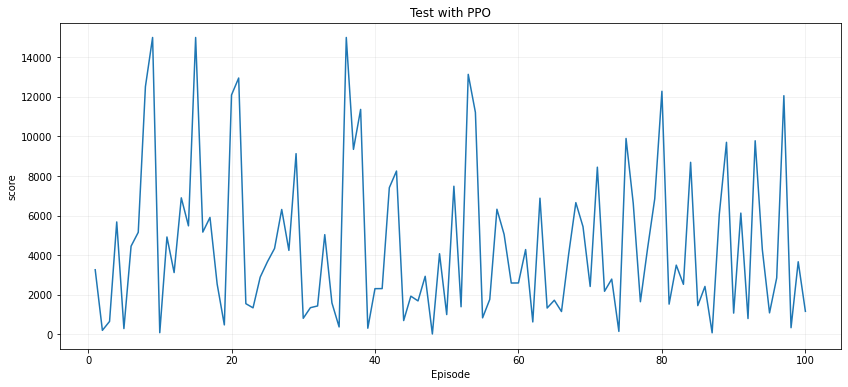

In [35]:
import matplotlib.pyplot as plt 

episodes = 100

episode_list_PPO = []
score_list_PPO = []

for episode in range(1, episodes+1):
    obs = env.reset()
    done = False
    score = 0

    while True:
        action, _states = model.predict(obs)
        obs, rewards, done, info = env.step(action)
        #print(obs)
        env.render()
        score+=rewards
        if done: 
            print('info', info)
            break
            
    print('Episode:{} Score:{}'.format(episode, score))
    score_list_PPO.append(score)
    episode_list_PPO.append(episode)

fig = plt.figure(figsize=(14,6))
plt.plot(episode_list_PPO, score_list_PPO)
plt.ylabel('score')
plt.xlabel('Episode')
plt.title('Test with PPO')
plt.grid(alpha=0.2)

### NOTE :Training beyond 65000 steps for PPO yeilds the perfect score of 15000, even for step-by-step evaluation.

In [36]:
env.close()

### Using tensor board

Change the log path to the log file. (uploaded with the best model data)

In [16]:
training_log_path = os.path.join(log_path, 'best_model')

In [17]:
!tensorboard --logdir={training_log_path}

^C


# A2C

In [222]:
from stable_baselines3 import A2C
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
import os 

### Training the model with callback and training stop at score threshold with defined architechture

In [223]:
save_path = os.path.join('Training', 'Saved Models','A2C_models')
log_path = os.path.join('Training', 'Logs','A2C_models')

In [224]:
env = CustomCartPoleEnv()
env = DummyVecEnv([lambda: env])

In [225]:
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=6000, verbose=1)# 6000 reward threshold because: 1 step = T = 0.02 sec assumed in the model. Hence 6000 steps = 2 minutes.
eval_callback = EvalCallback(env, 
                             callback_on_new_best=stop_callback, 
                             eval_freq=10000, 
                             best_model_save_path=save_path, 
                             verbose=1)

In [226]:
net_arch=[dict(pi=[128, 128, 128, 128], vf=[128, 128, 128, 128])]

In [227]:
A2Cmodel = A2C('MlpPolicy', env, verbose = 1, tensorboard_log=log_path, policy_kwargs={'net_arch': net_arch})

Using cpu device


In [228]:
A2Ctime_start = time.time()
A2Cmodel.learn(total_timesteps=70000, callback=eval_callback)
A2Ctime_stop = time.time()

Logging to Training\Logs\A2C_models\A2C_21
------------------------------------
| time/                 |          |
|    fps                | 892      |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.107   |
|    explained_variance | 0.00876  |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 0.0863   |
|    value_loss         | 7.82     |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 858      |
|    iterations         | 200      |
|    time_elapsed       | 1        |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -0.0444  |
|    explained_variance | -0.00054 |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | 0.0172

In [229]:
A2Ctrain_time = A2Ctime_stop -  A2Ctime_start
print(A2Ctrain_time)

67.64369487762451


In [216]:
model_path = os.path.join('Training', 'Saved Models','A2C_models', 'best_model')
model = A2C.load(model_path, env=env)

### NOTE: For presentation the following evaluate policy function was used: 

To get the scores used to plot the graphs in poster presentation, pass the following additional args and kwargs to evaluate_policy():

n_eval_episodes=100

return_episode_rewards=True (save the returned episode scores to a list)

NOTE : A step-by-step evalution of performance is done below, because the results from evalute policy function differs from the step-by-step evaluation. The evaluate policy function tends to return the perfect score of 15000 quite often, where as step by step evalution, returns more expected values.

In [217]:
evaluate_policy(model, env, n_eval_episodes=1, render=True)

(15000.0, 0.0)

In [203]:
env.close()

### Testing the trained model

In [230]:
env = CustomCartPoleEnv()
env = DummyVecEnv([lambda: env])

In [231]:
model_path = os.path.join('Training', 'Saved Models','A2C_models', 'best_model')
model = A2C.load(model_path, env=env)

In [232]:
import matplotlib.pyplot as plt 

episodes = 100

episode_list_A2C = []
score_list_A2C = []

for episode in range(1, episodes+1):
    obs = env.reset()
    done = False
    score = 0
    count = 0

    while True:
        action, _states = model.predict(obs)
        obs, rewards, done, info = env.step(action)
        #print(obs)
        env.render()
        score+=rewards
        if done: 
            print('info', info)
            break
            
    print('Episode:{} Score:{}'.format(episode, score))
    score_list_A2C.append(score)
    episode_list_A2C.append(episode)

fig = plt.figure(figsize=(14,6))
plt.plot(episode_list_A2C, score_list_A2C)
plt.ylabel('score')
plt.xlabel('Episode')
plt.title('Test with A2C')
plt.grid(alpha=0.2)

info [{'terminal_observation': array([0.5599614 , 0.01890933, 0.23100221, 0.20874648], dtype=float32)}]
Episode:1 Score:[1312.]
info [{'terminal_observation': array([ 0.5841552 , -0.24689643, -0.04953808,  2.7374213 ], dtype=float32)}]
Episode:2 Score:[15000.]
info [{'terminal_observation': array([ 0.4655665 , -0.12082604, -0.21118313,  0.8730145 ], dtype=float32)}]
Episode:3 Score:[749.]
info [{'terminal_observation': array([ 0.5017597 ,  0.04175478, -0.01197055, -0.60577935], dtype=float32)}]
Episode:4 Score:[15000.]
info [{'terminal_observation': array([ 0.6277949 ,  0.04617303, -0.01205695, -0.5123537 ], dtype=float32)}]
Episode:5 Score:[15000.]
info [{'terminal_observation': array([ 0.6498281 , -0.07915101,  0.20974807, -0.5679661 ], dtype=float32)}]
Episode:6 Score:[5389.]
info [{'terminal_observation': array([ 0.58736575, -0.03589918, -0.00687098,  0.5573538 ], dtype=float32)}]
Episode:7 Score:[15000.]
info [{'terminal_observation': array([ 0.55567014,  0.00227154, -0.03531681, 

KeyboardInterrupt: 

In [221]:
env.close()

### Using tensorboard

In [ ]:
training_log_path = os.path.join(log_path, 'best_model')

In [ ]:
!tensorboard --logdir={training_log_path}

# DQN

In [134]:
from stable_baselines3 import DQN

In [135]:
save_path = os.path.join('Training', 'Saved Models','DQN_models')
log_path = os.path.join('Training', 'Logs','DQN_models')

In [136]:
env = CustomCartPoleEnv()
env = DummyVecEnv([lambda: env])

In [137]:
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=6000, verbose=1)# 6000 reward threshold because: 1 step = T = 0.02 sec assumed in the model. Hence 6000 steps = 2 minutes.
eval_callback = EvalCallback(env, 
                             callback_on_new_best=stop_callback, 
                             eval_freq=10000, 
                             best_model_save_path=save_path, 
                             verbose=1)

In [138]:
DQNmodel = DQN('MlpPolicy', env, verbose = 1, tensorboard_log=log_path)#, policy_kwargs={'net_arch': net_arch})

Using cpu device


In [139]:
DQNtime_start = time.time()
DQNmodel.learn(total_timesteps=200000, callback=eval_callback)
DQNtime_stop = time.time()

Logging to Training\Logs\DQN_models\DQN_20
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1655     |
|    time_elapsed     | 0        |
|    total_timesteps  | 29       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2388     |
|    time_elapsed     | 0        |
|    total_timesteps  | 49       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.996    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 3444     |
|    time_elapsed     | 0        |
|    total_timesteps  | 81       |
----------------------------------
------------

In [141]:
DQNtrain_time = DQNtime_stop -  DQNtime_start
print(DQNtrain_time)

93.69132280349731


In [108]:
model_path = os.path.join('Training', 'Saved Models','DQN_models', 'best_model')
model = DQN.load(model_path, env=env)# Load the best model

In [109]:
evaluate_policy(model, env, n_eval_episodes=1, render=True)

(384.0, 0.0)

In [110]:
env.close()

### Testing the trained model

In [169]:
env = CustomCartPoleEnv()
env = DummyVecEnv([lambda: env])

In [170]:
model_path = os.path.join('Training', 'Saved Models','DQN_models', 'best_model')
model = DQN.load(model_path, env=env)

info [{'terminal_observation': array([ 0.04254421,  0.121746  , -0.23279412, -1.642197  ], dtype=float32)}]
Episode:1 Score:[25.]
info [{'terminal_observation': array([-0.10235929,  0.0483068 ,  0.21137255, -0.74379027], dtype=float32)}]
Episode:2 Score:[152.]
info [{'terminal_observation': array([-0.4215236 , -0.39854035,  0.23355126,  1.5790325 ], dtype=float32)}]
Episode:3 Score:[215.]
info [{'terminal_observation': array([-0.08915744, -0.71921235,  0.30135974, 10.930428  ], dtype=float32)}]
Episode:4 Score:[47.]
info [{'terminal_observation': array([1.0144151 , 0.79077363, 0.09069273, 2.1713102 ], dtype=float32)}]
Episode:5 Score:[202.]
info [{'terminal_observation': array([ 1.0074892 ,  0.98556066,  0.16157663, -0.721713  ], dtype=float32)}]
Episode:6 Score:[250.]
info [{'terminal_observation': array([1.0053393 , 0.75141686, 0.07763029, 2.2750754 ], dtype=float32)}]
Episode:7 Score:[222.]
info [{'terminal_observation': array([-0.4960887 , -0.37796754, -0.23107117, -1.4611126 ], dt

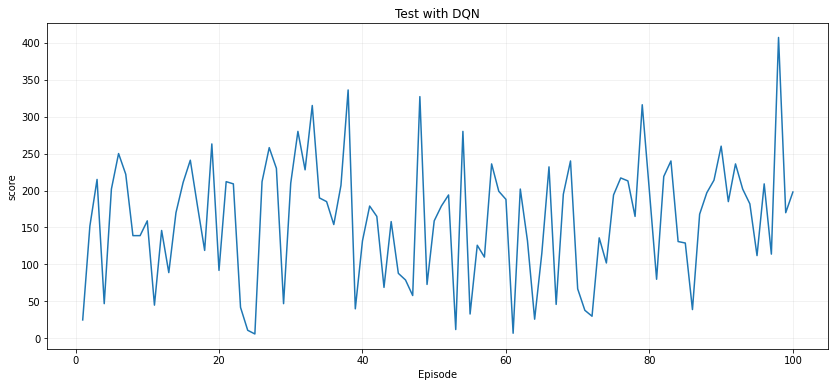

In [171]:
import matplotlib.pyplot as plt 

episodes = 100

episode_list_DQN = []
score_list_DQN = []

for episode in range(1, episodes+1):
    obs = env.reset()
    done = False
    score = 0

    while True:
        action, _states = model.predict(obs)
        obs, rewards, done, info = env.step(action)
        env.render()
        score+=rewards
        if done: 
            print('info', info)
            break
            
    print('Episode:{} Score:{}'.format(episode, score))
    score_list_DQN.append(score)
    episode_list_DQN.append(episode)

fig = plt.figure(figsize=(14,6))
plt.plot(episode_list_DQN, score_list_DQN)
plt.ylabel('score')
plt.xlabel('Episode')
plt.title('Test with DQN')
plt.grid(alpha=0.2)

In [44]:
env.close()

### Using tensorboard

In [ ]:
training_log_path = os.path.join(log_path, 'best_model')

In [ ]:
!tensorboard --logdir={training_log_path}

# QR-DQN

In [295]:
#!pip install sb3-contrib

In [111]:
from sb3_contrib import QRDQN

In [112]:
save_path = os.path.join('Training', 'Saved Models','QRDQN_models')
log_path = os.path.join('Training', 'Logs','QRDQN_models')

In [113]:
env = CustomCartPoleEnv()
env = DummyVecEnv([lambda: env])

In [114]:
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=6000, verbose=1)# 6000 reward threshold because: 1 step = T = 0.02 sec assumed in the model. Hence 6000 steps = 2 minutes.
eval_callback = EvalCallback(env, 
                             callback_on_new_best=stop_callback, 
                             eval_freq=10000, 
                             best_model_save_path=save_path, 
                             verbose=1)

In [115]:
#policy_kwargs = dict(n_quantiles=50)
QRmodel = QRDQN('MlpPolicy', env, verbose = 1, tensorboard_log=log_path)#policy_kwargs not varied

Using cpu device


In [116]:
time_start = time.time()
QRmodel.learn(total_timesteps=200000, callback=eval_callback)
time_stop = time.time()

Logging to Training\Logs\QRDQN_models\QRDQN_10
----------------------------------
| rollout/            |          |
|    exploration rate | 0.977    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3285     |
|    time_elapsed     | 0        |
|    total_timesteps  | 23       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration rate | 0.938    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 5725     |
|    time_elapsed     | 0        |
|    total_timesteps  | 63       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration rate | 0.911    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 6427     |
|    time_elapsed     | 0        |
|    total_timesteps  | 90       |
----------------------------------
--------

In [133]:
QRtrain_time = time_stop -  time_start
print(train_time)

1070.49178647995


In [87]:
model_path = os.path.join('Training', 'Saved Models','QRDQN_models', 'best_model')
model = QRDQN.load(model_path, env=env)# Load the best model

In [63]:
evaluate_policy(model, env, n_eval_episodes=1, render=True)

(6.0, 0.0)

In [65]:
env.close()

### Testing the trained model

In [166]:
env = CustomCartPoleEnv()
env = DummyVecEnv([lambda: env])

In [167]:
model_path = os.path.join('Training', 'Saved Models','QRDQN_models', 'best_model')
model = QRDQN.load(model_path, env=env)

info [{'terminal_observation': array([ 1.0045497 ,  0.7949307 ,  0.02270999, -2.0987115 ], dtype=float32)}]
Episode:1 Score:[184.]
info [{'terminal_observation': array([ 0.00959838, -0.00535527, -0.22273253, -0.9231482 ], dtype=float32)}]
Episode:2 Score:[18.]
info [{'terminal_observation': array([-1.0084199 , -1.024197  , -0.10829284, -2.2281506 ], dtype=float32)}]
Episode:3 Score:[176.]
info [{'terminal_observation': array([-0.0522697 ,  0.0981839 ,  0.21875696, -0.557863  ], dtype=float32)}]
Episode:4 Score:[29.]
info [{'terminal_observation': array([-1.0044875 , -1.0572361 , -0.13604212, -0.15958282], dtype=float32)}]
Episode:5 Score:[180.]
info [{'terminal_observation': array([ 0.47077736,  0.1502587 , -0.22296587,  0.8237875 ], dtype=float32)}]
Episode:6 Score:[191.]
info [{'terminal_observation': array([-0.98114705, -1.1312617 , -0.22569942,  0.06727969], dtype=float32)}]
Episode:7 Score:[163.]
info [{'terminal_observation': array([-1.0138122 , -1.2304139 , -0.16930704,  1.67016

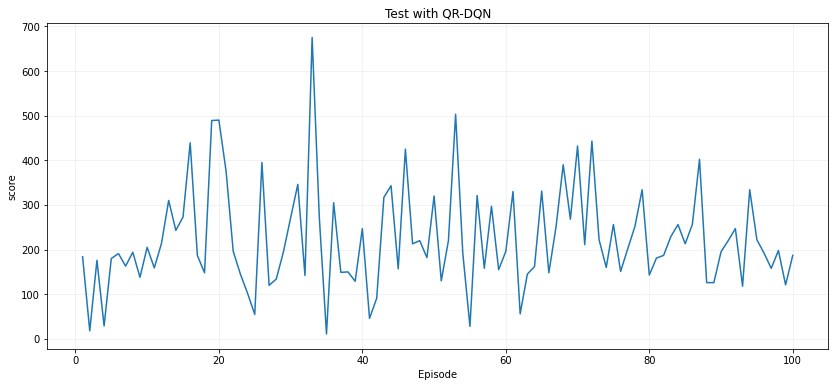

In [168]:
import matplotlib.pyplot as plt 

episodes = 100
rewards = 0
episode_list_QR = []
score_list_QR = []

for episode in range(1, episodes+1):
    obs = env.reset()
    done = False
    score = 0

    while True:
        action, _states = model.predict(obs)
        obs, rewards, done, info = env.step(action)
        env.render()
        score+=rewards
        if done: 
            print('info', info)
            break
            
    print('Episode:{} Score:{}'.format(episode, score))
    score_list_QR.append(score)
    episode_list_QR.append(episode)

fig = plt.figure(figsize=(14,6))
plt.plot(episode_list_QR, score_list_QR)
plt.ylabel('score')
plt.xlabel('Episode')
plt.title('Test with QR-DQN')
plt.grid(alpha=0.2)

In [94]:
env.close()

### Using tensorboard

In [ ]:
training_log_path = os.path.join(log_path, 'best_model')

In [ ]:
!tensorboard --logdir={training_log_path}

# Visualizing the testing data

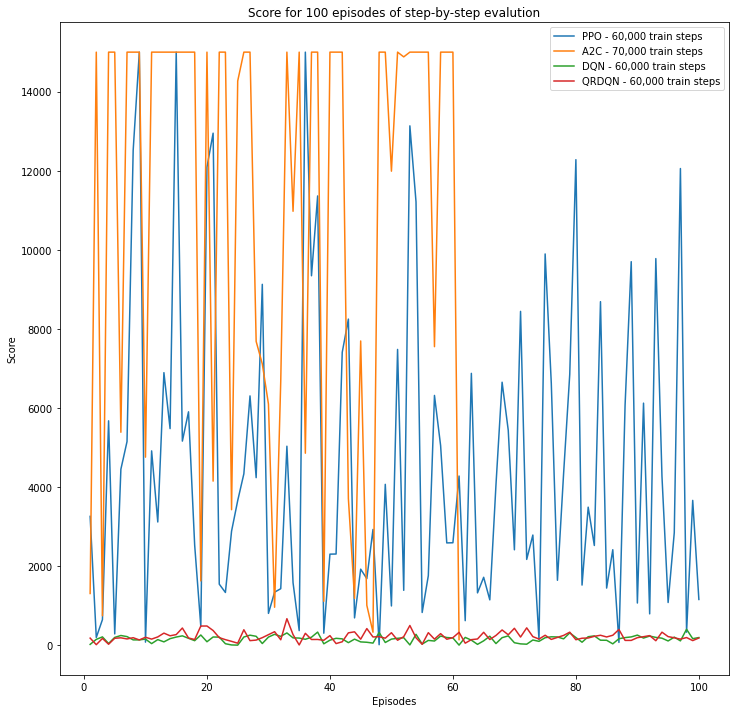

In [233]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

plt.plot(episode_list_PPO, score_list_PPO, label = "PPO - 60,000 train steps")

plt.plot(episode_list_A2C, score_list_A2C, label = "A2C - 70,000 train steps")

plt.plot(episode_list_DQN, score_list_DQN, label = "DQN - 60,000 train steps")

plt.plot(episode_list_QR, score_list_QR, label = "QRDQN - 60,000 train steps")

plt.xlabel('Episodes')
plt.ylabel('Score')
plt.title('Score for 100 episodes of step-by-step evalution')

plt.legend()

plt.show()


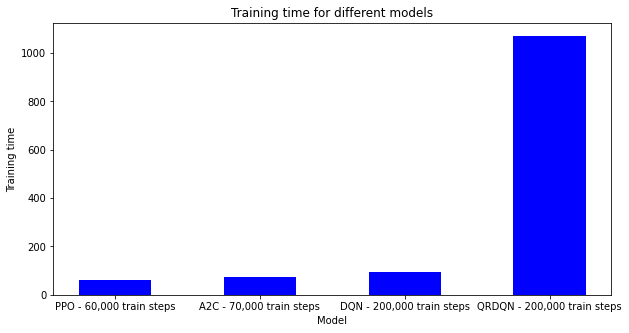

In [152]:
model_dict = {'PPO - 60,000 train steps':PPOtrain_time,'A2C - 70,000 train steps':A2Ctrain_time,'DQN - 200,000 train steps':DQNtrain_time,'QRDQN - 200,000 train steps':QRtrain_time} 

model_name = list(model_dict.keys())
time = list(model_dict.values())

fig = plt.figure(figsize = (10, 5))

plt.bar(model_name, time, color ='blue',
        width = 0.5)
plt.xlabel("Model")
plt.ylabel("Training time")
plt.title('Training time for different models')
plt.show()


# Conclusion:
PPO and A2C performed better, achieving the perfect score of 15000 in less than 70,000 total training steps. Though the learning rate of PPO model is higher initially, A2C trained model was found to achieve perfect score sooner i.e. with fewer total training steps.
Thus, if the physical robot is required to be trained to stand upright using transfer model based learning. A model trained in simulation environment with A2C RL algorithm, would be the best choice among the four tested

# Testing the bluetooth connection with robot

In [ ]:
#!pip install pyserial

In [ ]:
import serial
from IPython.display import clear_output

In [ ]:
ser = serial.Serial("COM5", 57600, timeout = 1) #Change your port name COM... and your baudrate

In [ ]:
import math
count = 0
bit = True

PPR_const = 0.0002656923077#pulse per meter
vel_const = 0.053138461#m/s per pulse

def retrieveData(bit):
    ser.write(b'e')
    clear_output(wait=True)
    data = ser.readline()
    #print(data)
    if (data == b'S\r\n'):
        x =  float(ser.readline().decode('ascii'))*PPR_const
        x_dot = float(ser.readline().decode('ascii'))*vel_const
        theta = float(ser.readline().decode('ascii'))* 2 * math.pi / 360
        theta_dot = float(ser.readline().decode('ascii'))* 2 * math.pi / 360
        
        print("x = ",x)
        print("x_dot = ",x_dot)
        print("theta = ",theta)
        print("theta_dot = ",theta_dot)
        
        if (bit):
            ser.write(b'1')
            print("right")
        else:
            ser.write(b'0')
            print("left")
            
while(True):
    count += 1
    if(count >= 100):
        count = 0
        bit = not bit
    retrieveData(bit)


# Control environment for inverted pendulum robot

In [1]:
import gym 
from gym import Env
from gym.spaces import Discrete, Box, Dict, Tuple, MultiBinary, MultiDiscrete 
import numpy as np
import random
import os
import math

In [2]:
from stable_baselines3 import PPO
from stable_baselines3 import A2C
from stable_baselines3 import DQN
from sb3_contrib import QRDQN
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv

In [3]:
import serial
from IPython.display import clear_output

In [4]:
ser = serial.Serial("COM5", 57600, timeout = 1) #Change your port name COM... and your baudrate

In [5]:
# Define functions for exchanging data with the robot.

PPR_const = 0.0002656923077#pulse per meter
vel_const = 0.053138461#m/s per pulse

def get_state(state):
    ser.write(b'e')
    got_data = False
    got_x = False
    got_x_dot = False
    got_theta = False
    got_theta_dot = False
    
    while (not got_data):
        data = ser.readline()
        if (data == b'S\r\n'):
            got_data = True
    
        x_temp =  ser.readline().decode('ascii')
        x_dot_temp = ser.readline().decode('ascii')
        theta_temp = ser.readline().decode('ascii')
        theta_dot_temp = ser.readline().decode('ascii')
        
        try:
            x_ = float(x_temp)*PPR_const
            got_x = True
        except:
            got_x = False
        
        try:
            x_dot = float(x_dot_temp)*vel_const
            got_x_dot = True
        except:
            got_x_dot = False
            
        try:
            theta = float(theta_temp)* 2 * math.pi / 360
            got_theta = True
        except:
            got_theta = False
        
        try:
            theta_dot = float(theta_dot_temp)* 2 * math.pi / 360
            got_theta_dot = True
        except:
            got_theta_dot = False

    if (got_x and got_x_dot and got_theta and got_theta_dot):
        return x_,x_dot,theta,theta_dot
    else:
        return state

def get_initial_state():
    got_data = False
    got_x = False
    got_x_dot = False
    got_theta = False
    got_theta_dot = False
    
    while (not got_data):
        ser.write(b'i')
        data = ser.readline()
        if (data == b'S\r\n'):
            x_temp =  ser.readline().decode('ascii')
            x_dot_temp = ser.readline().decode('ascii')
            theta_temp = ser.readline().decode('ascii')
            theta_dot_temp = ser.readline().decode('ascii')
            
            try:
                x_ = float(x_temp)*PPR_const
                got_x = True
            except:
                got_x = False
        
            try:
                x_dot = float(x_dot_temp)*vel_const
                got_x_dot = True
            except:
                got_x_dot = False

            try:
                theta = float(theta_temp)* 2 * math.pi / 360
                got_theta = True
            except:
                got_theta = False

            try:
                theta_dot = float(theta_dot_temp)* 2 * math.pi / 360
                got_theta_dot = True
            except:
                got_theta_dot = False

            got_data = (got_x and got_x_dot and got_theta and got_theta_dot)

    return x_,x_dot,theta,theta_dot
    
def set_action(act):
    if (act == 0):
        ser.write(b'0')
    elif (act == 1):
        ser.write(b'1')
        

In [7]:
import math
from typing import Optional, Union

import numpy as np

import gym
from gym import Env
from gym import logger, spaces
from gym.utils import seeding
from gym.spaces import Discrete, Box, Dict, Tuple, MultiBinary, MultiDiscrete 

import serial
from IPython.display import clear_output


class Robo_Env(Env):
    
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 50}
    
    def __init__(self):
        
        self.gravity = 9.8
        self.masscart = 0.642
        self.masspole = 0.113
        self.total_mass = self.masspole + self.masscart
        self.length = 0.044  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag = 2*2.376
        self.tau = 0.02  # seconds between state updates
        self.kinematics_integrator = "euler"
        self.max_episode = 15000 # 2 mins real time

        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 1.0 #2.4
        
        # Actions robot can take : Left(0), right(1)
        self.action_space = Discrete(2)
        
        # Observation space
        high = np.array(
            [
                self.x_threshold * 2,
                0.5874,
                #np.finfo(np.float32).max,
                self.theta_threshold_radians * 2,
                np.finfo(np.float32).max,
                #0.74, # 170 RPM max for motor and diameter of wheel 6.6 cm, hence max velocity = 58.74 cm/s. The experiment setup gives 0.74

            ],
            dtype=np.float32,
        )

        self.observation_space = spaces.Box(-high, high, dtype=np.float32)
        
        reward = 0
        
        self.screen = None
        self.clock = None
        self.isopen = True
        self.state = None

        self.steps_beyond_done = None
        
        
        self.state = get_initial_state()
    
    def step(self, action):
        done = False
        self.state = get_state(self.state)
        set_action(action)
        
        if not done:
            
            reward = 1
            
        else:
            ser.write(b'x')
            reward = 0

        return np.array(self.state, dtype=np.float32), reward, done, {}

    def render(self, mode="human"):
        import pygame
        from pygame import gfxdraw

        screen_width = 900#600
        screen_height = 600#400

        world_width = self.x_threshold * 2
        scale = screen_width / world_width
        polewidth = int(scale*0.1)
        polelen = int(scale * (2 * self.length))

        #cartwidth = 50.0
        #cartheight = 30.0
        wheel_rad = int(scale*0.033)#9.9cm dia

        if self.state is None:
            return None

        x = self.state

        if self.screen is None:
            pygame.init()
            pygame.display.init()
            self.screen = pygame.display.set_mode((screen_width, screen_height))
        if self.clock is None:
            self.clock = pygame.time.Clock()

        self.surf = pygame.Surface((screen_width, screen_height))
        self.surf.fill((255, 255, 255))

        cartx = x[0] * scale + screen_width / 2.0  # MIDDLE OF wheel
        carty = int(screen_height/4) + wheel_rad  # TOP OF wheel
        axleoffset = polewidth / 2 #wheel_ra

        l, r, t, b = (
            -polewidth / 2,
            polewidth / 2,
            polelen - polewidth / 2,
            -polewidth / 2,
        )

        l1, r1, t1, b1 = (
            -polewidth / 4,
            polewidth / 4,
            polelen - polewidth / 2,
            -polewidth / 2,
        )

        pole_coords = []
        box_coords = []

        for coord in [(l1, b1), (l1, t1), (r1, t1), (r1, b1)]:
            coord = pygame.math.Vector2(coord).rotate_rad(-x[2])
            coord = (coord[0] + cartx, coord[1] + carty + axleoffset)
            box_coords.append(coord)

        for coord in [(l, b), (l, t), (r, t), (r, b)]:
            coord = pygame.math.Vector2(coord).rotate_rad(-x[2])
            coord = (coord[0] + cartx, coord[1] + carty + axleoffset)
            pole_coords.append(coord)

        gfxdraw.aapolygon(self.surf, pole_coords, (0, 0, 0))

        gfxdraw.filled_polygon(self.surf, pole_coords, (202, 152, 101))

        gfxdraw.filled_polygon(self.surf, box_coords, (0, 0, 0))

        gfxdraw.aacircle(self.surf, int(cartx), int(carty), wheel_rad, (0, 0, 250))
        gfxdraw.filled_circle(self.surf, int(cartx), int(carty), wheel_rad, (0, 0, 250))

        gfxdraw.aacircle(
            self.surf,
            int(cartx),
            #int(carty + axleoffset),
            int(carty),
            int(wheel_rad / 2),
            (129, 132, 203),
        )
        gfxdraw.filled_circle(
            self.surf,
            int(cartx),
            #int(carty + axleoffset),
            int(carty),
            int(wheel_rad / 2),
            (0, 250, 250),
        )


        gfxdraw.hline(self.surf, 0, screen_width, carty - wheel_rad, (0, 0, 0))

        self.surf = pygame.transform.flip(self.surf, False, True)
        self.screen.blit(self.surf, (0, 0))
        if mode == "human":
            pygame.event.pump()
            self.clock.tick(self.metadata["render_fps"])
            pygame.display.flip()

        if mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )
        else:
            return self.isopen

    
    
    def reset(self):
        reward = 0
        return self.state
    
    def close(self):
        if self.screen is not None:
            import pygame

            pygame.display.quit()
            pygame.quit()
            self.isopen = False

In [ ]:
env = Robo_Env()
env = DummyVecEnv([lambda: env])
model_path = os.path.join('Training', 'Saved Models','A2C_models', 'best_model')
model = A2C.load(model_path, env=env)
obs = env.reset()
score = 0
done = False
while True:
        action, _states = model.predict(obs)
        obs, rewards, done, info = env.step(action)
        print(obs)
        #env.render()
        score+=rewards
        if done: 
            print('info', info)
            break

In [14]:
env.close()

In [ ]:
obs = env.reset()
score = 0
done = False
start_robot()
while True:
        action, _states = model.predict(obs)
        obs, rewards, done, info = env.step(action)
        print(obs)
        #env.render()
        score+=rewards
        if done: 
            print('info', info)
            break